In [1]:

import numpy as np
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2


# Superdense coding

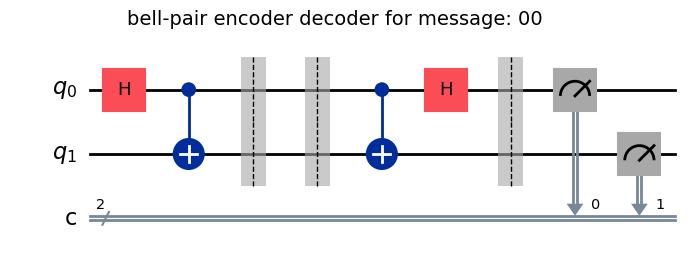

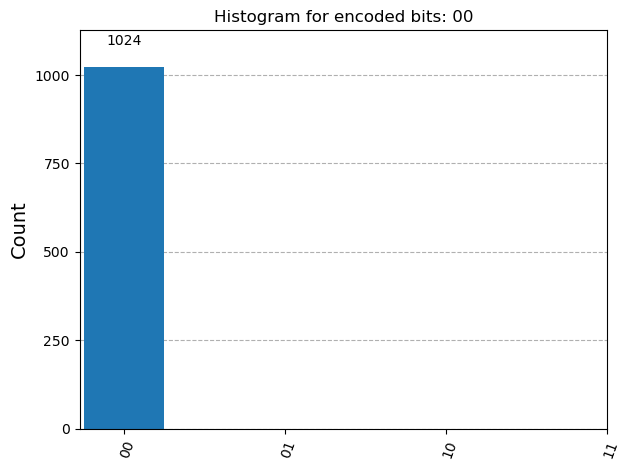

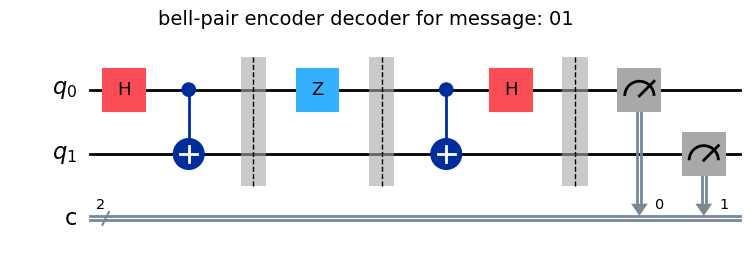

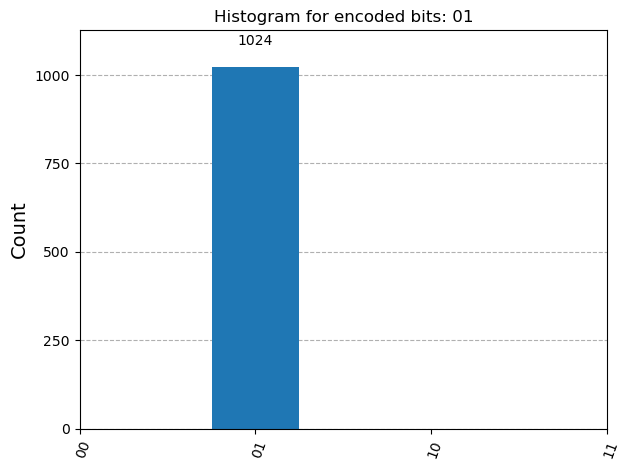

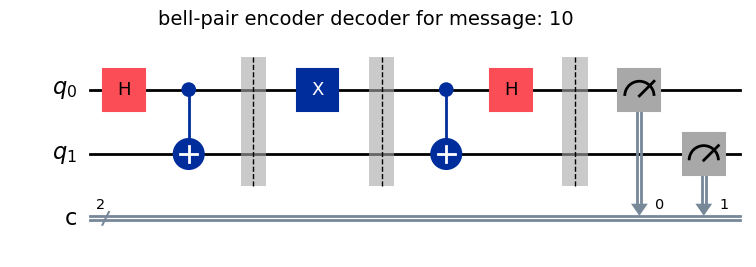

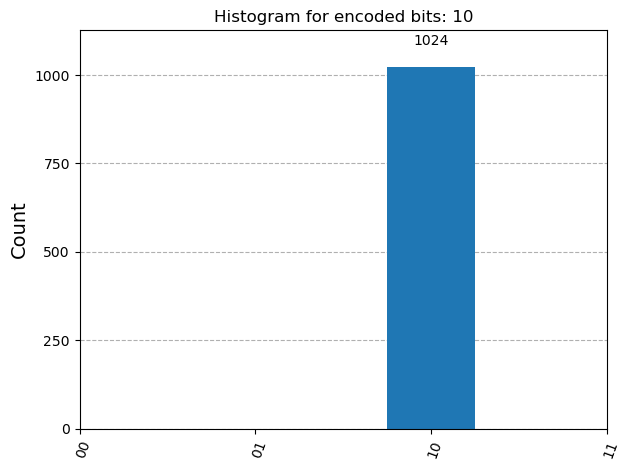

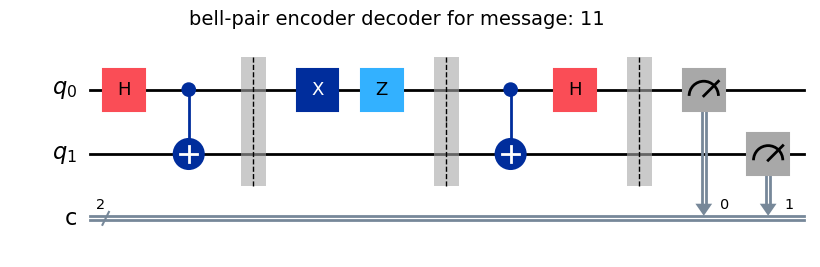

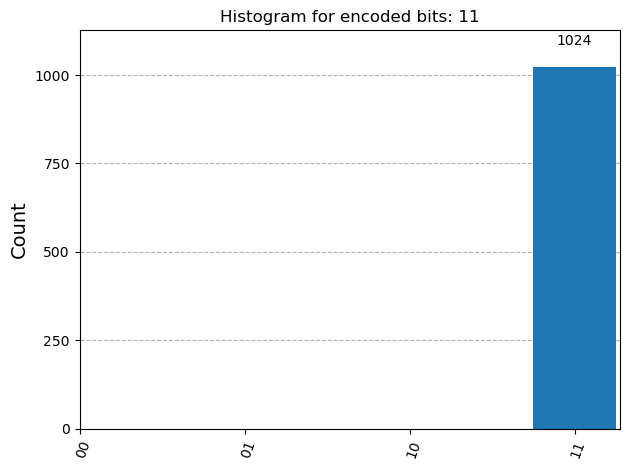

In [67]:
for bits in ['00', '01', '10', '11']:

    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)
    qc.h(qr[0])
    qc.cx(qr[0], qr[1])
    qc.barrier()
    if bits[0] == '1':
        qc.x(qr[0])
    if bits[1] == '1':
        qc.z(qr[0])
    qc.barrier()
    qc.cx(qr[0], qr[1])
    qc.h(qr[0])
    qc.barrier()
    qc.measure(qr, cr)

    title = f"bell-pair encoder decoder for message: {bits}"
    fig = qc.draw('mpl')
    fig.suptitle(title, fontsize=14)
    display(fig)

    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    
    dict_results = {'00': 0, '01': 0, '10': 0, '11': 0}
    dict_results[list(result.get_counts(qc).keys())[0]] = list(result.get_counts(qc).values())[0]
    #print(dict_results)
    title = f"Histogram for encoded bits: {bits}"
    display(plot_histogram(dict_results, title=title))


# Superdense coding (bell-pair, encoder, decoder in separate module)

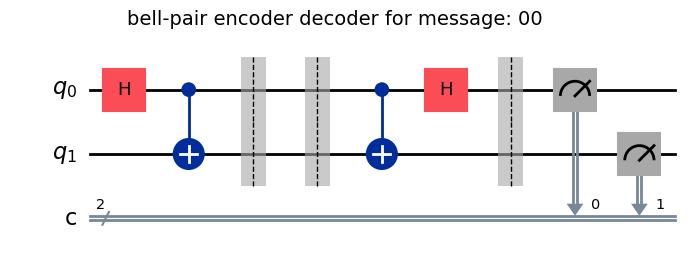

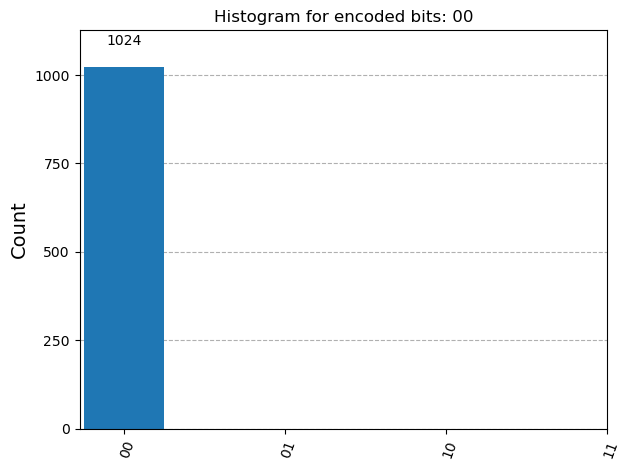

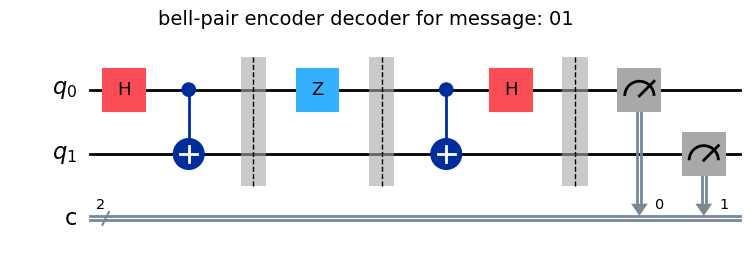

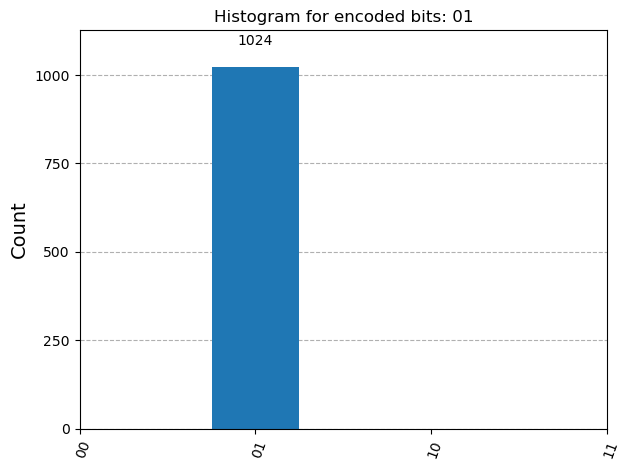

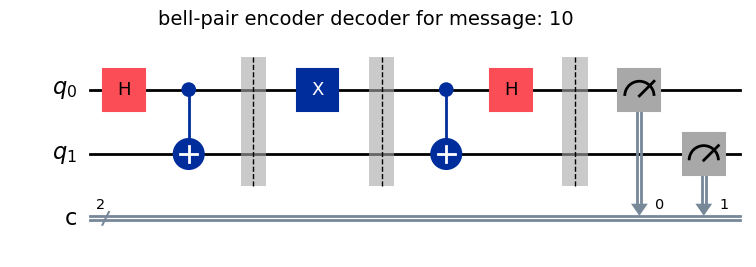

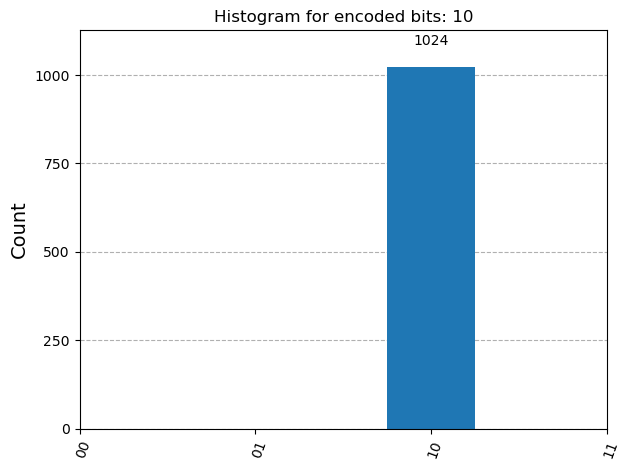

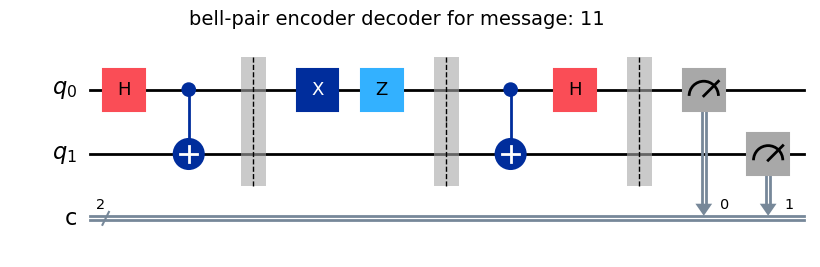

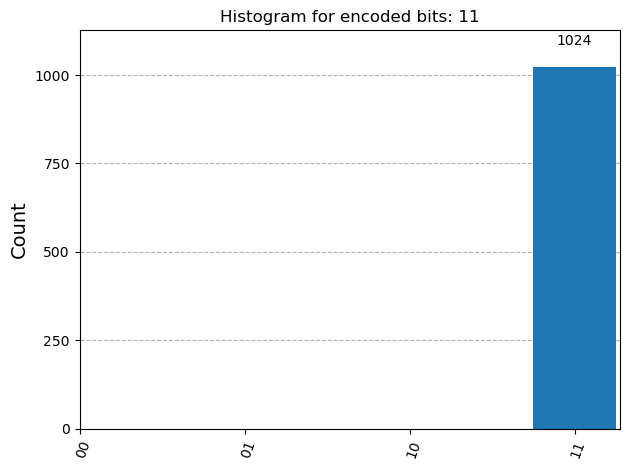

In [66]:
def bell_pair(qc):
    qc.h(0)
    qc.cx(0, 1)
    return qc

def encoder(qc, bits):
    if bits[0] == '1':
        qc.x(0)
    if bits[1] == '1':
        qc.z(0)
    return qc

def decoder(qc):
    qc.cx(0, 1)
    qc.h(0)
    return qc

for bits in ['00', '01', '10', '11']:

    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)
    bell_pair(qc)
    qc.barrier()
    encoder(qc, bits)
    qc.barrier()
    decoder(qc)
    qc.barrier()
    qc.measure(qr, cr)

    title = f"bell-pair encoder decoder for message: {bits}"
    fig = qc.draw('mpl')
    fig.suptitle(title, fontsize=14)
    display(fig)

    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    
    dict_results = {'00': 0, '01': 0, '10': 0, '11': 0}
    dict_results[list(result.get_counts(qc).keys())[0]] = list(result.get_counts(qc).values())[0]
    #print(dict_results)
    title = f"Histogram for encoded bits: {bits}"
    display(plot_histogram(dict_results, title=title))